# Dataset Download


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.7 MB/s eta 0:00:00


In [3]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [ ]:
!kaggle competitions list -s "home-credit"

ref                                                                             deadline             category        reward  teamCount  userHasEntered  userRank  
------------------------------------------------------------------------------  -------------------  ---------  -----------  ---------  --------------  --------  
https://www.kaggle.com/competitions/home-credit-credit-risk-model-stability     2024-05-27 23:59:00  Featured   105,000 Usd       3856           False         0  
https://www.kaggle.com/competitions/home-credit-default-risk                    2018-08-29 23:59:00  Featured    70,000 Usd       7176            True         0  
https://www.kaggle.com/competitions/home-credit-credit-risk-modeling            2024-05-24 01:00:00  Community        Kudos         37           False         0  
https://www.kaggle.com/competitions/pred-411-2016-09-u2-bingo-heloc             2016-12-31 23:59:00  Community    Knowledge         35           False         0  
https://www.kaggle.com

In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/ML_Projects/Credit_Risk/data"
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle competitions download \
    -c home-credit-default-risk \
    -p "$DATA_DIR"

100% 688M/688M [00:07<00:00, 99.8MB/s]



In [4]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('home-credit-default-risk')

print("Path to competition files:", path)

100%|██████████| 688M/688M [00:17<00:00, 41.5MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/home-credit-default-risk


## BaseLine Model

In [5]:
import pandas as pd
import os

train_path = os.path.join(path, "application_train.csv")
df_train = pd.read_csv(train_path)
df_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [7]:
df_train["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


## Target Distribution

In [8]:
print(df_train["TARGET"].value_counts(normalize=True) * 100)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


## Missing Values

In [9]:
missing = df_train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing.head(30)

,0
COMMONAREA_MEDI,214865
COMMONAREA_MODE,214865
COMMONAREA_AVG,214865
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


In [10]:
df_train["DAYS_EMPLOYED"].describe()

,DAYS_EMPLOYED
count,307511.000000
mean,63815.045904
std,141275.766519
min,-17912.000000
25%,-2760.000000
50%,-1213.000000
75%,-289.000000
max,365243.000000


In [11]:
df_train[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].isnull().sum()

,0
EXT_SOURCE_1,173378
EXT_SOURCE_2,660
EXT_SOURCE_3,60965


In [12]:
print(
    "Columns with >50% missing:",
    (df_train.isnull().mean() > 0.50).sum()
)

Columns with >50% missing: 41


In [6]:
high_missing_cols = (
    df_train.columns[
        df_train.isnull().mean() > 0.50
    ]
)

for col in high_missing_cols:
    print(
        f"{col:40} "
        f"{df_train[col].isnull().mean()*100:.2f}%"
    )

OWN_CAR_AGE                              65.99%
EXT_SOURCE_1                             56.38%
APARTMENTS_AVG                           50.75%
BASEMENTAREA_AVG                         58.52%
YEARS_BUILD_AVG                          66.50%
COMMONAREA_AVG                           69.87%
ELEVATORS_AVG                            53.30%
ENTRANCES_AVG                            50.35%
FLOORSMIN_AVG                            67.85%
LANDAREA_AVG                             59.38%
LIVINGAPARTMENTS_AVG                     68.35%
LIVINGAREA_AVG                           50.19%
NONLIVINGAPARTMENTS_AVG                  69.43%
NONLIVINGAREA_AVG                        55.18%
APARTMENTS_MODE                          50.75%
BASEMENTAREA_MODE                        58.52%
YEARS_BUILD_MODE                         66.50%
COMMONAREA_MODE                          69.87%
ELEVATORS_MODE                           53.30%
ENTRANCES_MODE                           50.35%
FLOORSMIN_MODE                          

In [14]:
df_raw = df_train.copy()

## EDA

In [7]:
categorical_cols = df_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = df_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numerical_cols))

Categorical features: 16
Numerical features: 106


In [16]:
df_train[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [17]:
for col in categorical_cols:
    print("\n" + "=" * 60)
    print(col)
    print(df_train[col].value_counts(dropna=False).head(10))


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / s

In [8]:
income_default = (
    df_train.groupby("NAME_INCOME_TYPE")["TARGET"]
    .agg(
        Default_Rate="mean",
        Applications="count"
    )
    .sort_values(
        "Default_Rate",
        ascending=False
    )
)

income_default

,Default_Rate,Applications
NAME_INCOME_TYPE,,
Maternity leave,0.400000,5
Unemployed,0.363636,22
Working,0.095885,158774
Commercial associate,0.074843,71617
State servant,0.057550,21703
Pensioner,0.053864,55362
Businessman,0.000000,10
Student,0.000000,18


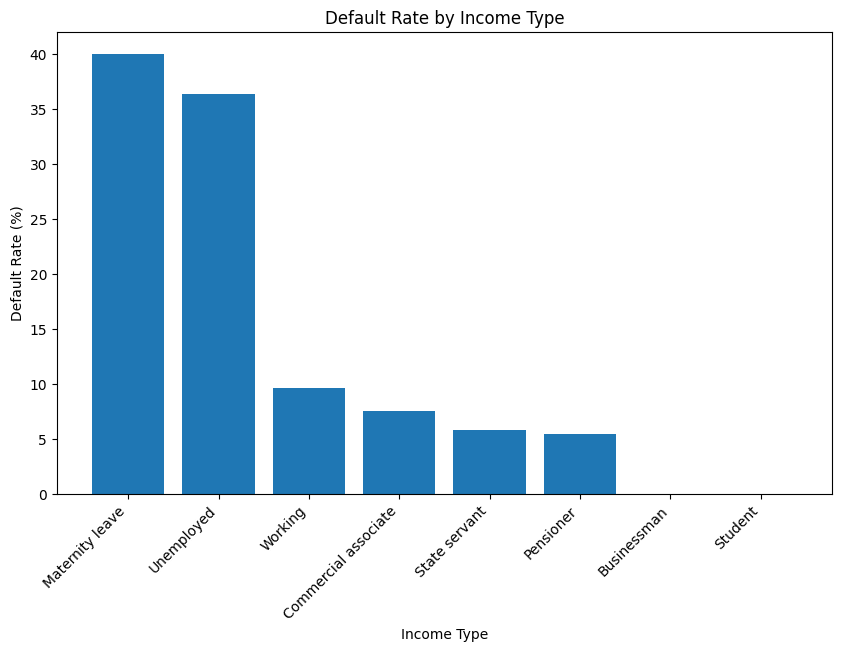

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    income_default.index,
    income_default["Default_Rate"] * 100
)

plt.title("Default Rate by Income Type")
plt.xlabel("Income Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [9]:
education_default = (
    df_train.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .agg(
        Default_Rate="mean",
        Applications="count"
    )
    .sort_values(
        "Default_Rate",
        ascending=False
    )
)

education_default

,Default_Rate,Applications
NAME_EDUCATION_TYPE,,
Lower secondary,0.109277,3816
Secondary / secondary special,0.089399,218391
Incomplete higher,0.084850,10277
Higher education,0.053551,74863
Academic degree,0.018293,164


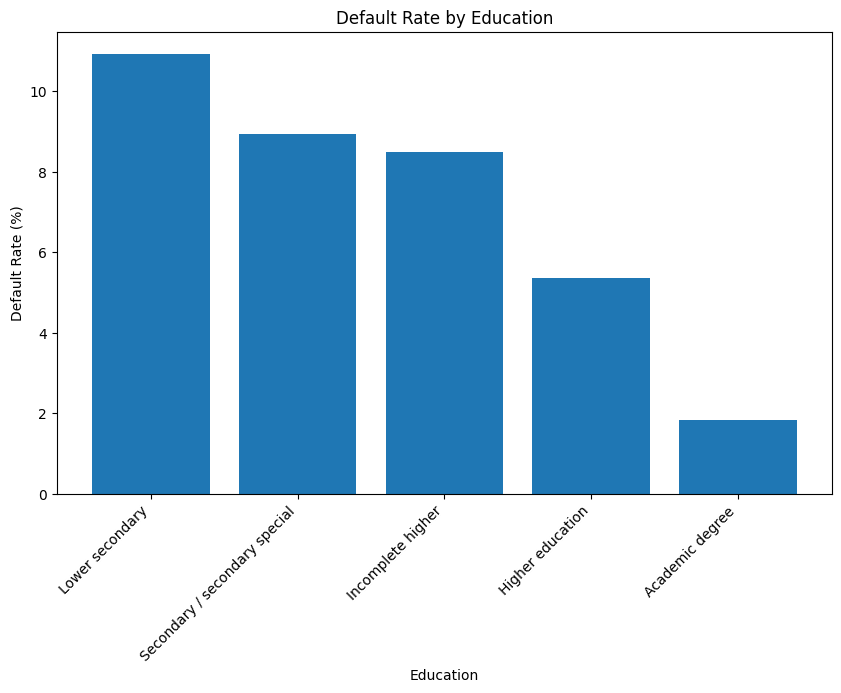

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(
    education_default.index,
    education_default["Default_Rate"] * 100
)

plt.title("Default Rate by Education")
plt.xlabel("Education")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [22]:
contract_default = (
    df_train.groupby("NAME_CONTRACT_TYPE")["TARGET"]
    .mean()
)

contract_default

,TARGET
NAME_CONTRACT_TYPE,
Cash loans,0.083459
Revolving loans,0.054783


## Feature Engineering

In [10]:
df_train["AGE_YEARS"] = (
    -df_train["DAYS_BIRTH"] / 365.25
)

In [24]:
df_train["AGE_YEARS"].describe()

,AGE_YEARS
count,307511.000000
mean,43.906900
std,11.947950
min,20.503765
25%,33.984942
50%,43.121150
75%,53.886379
max,69.073238


In [25]:
df_train.groupby("TARGET")["AGE_YEARS"].mean()

,AGE_YEARS
TARGET,
0,44.183919
1,40.752438


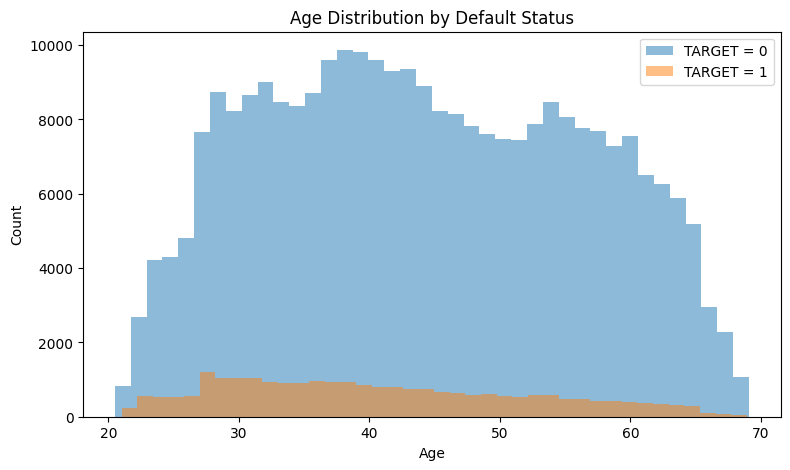

In [26]:
plt.figure(figsize=(9, 5))

for target in [0, 1]:
    plt.hist(
        df_train.loc[
            df_train["TARGET"] == target,
            "AGE_YEARS"
        ].dropna(),
        bins=40,
        alpha=0.5,
        label=f"TARGET = {target}"
    )

plt.title("Age Distribution by Default Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()

plt.show()

In [11]:
print(
    "Anomalous DAYS_EMPLOYED:",
    (df_train["DAYS_EMPLOYED"] == 365243).sum()
)

Anomalous DAYS_EMPLOYED: 55374


In [12]:
import numpy as np

df_train["DAYS_EMPLOYED"] = df_train[
    "DAYS_EMPLOYED"
].replace(
    365243,
    np.nan
)

In [13]:
df_train["EMPLOYED_YEARS"] = (
    -df_train["DAYS_EMPLOYED"] / 365.25
)

In [30]:
df_train["EMPLOYED_YEARS"].describe()

,EMPLOYED_YEARS
count,252137.000000
mean,6.527500
std,6.402081
min,-0.000000
25%,2.099932
50%,4.511978
75%,8.692676
max,49.040383


In [14]:
df_train["CREDIT_INCOME_RATIO"] = (
    df_train["AMT_CREDIT"] /
    df_train["AMT_INCOME_TOTAL"]
)

In [15]:
df_train["ANNUITY_INCOME_RATIO"] = (
    df_train["AMT_ANNUITY"] /
    df_train["AMT_INCOME_TOTAL"]
)

In [16]:
df_train["CREDIT_ANNUITY_RATIO"] = (
    df_train["AMT_CREDIT"] /
    df_train["AMT_ANNUITY"]
)

In [18]:
ratio_cols = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO"
]

df_train[ratio_cols] = df_train[ratio_cols].replace(
    [np.inf, -np.inf],
    np.nan
)

In [35]:
correlation = (
    df_train[numerical_cols + [
        "AGE_YEARS",
        "EMPLOYED_YEARS",
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_ANNUITY_RATIO"
    ]]
    .corr()["TARGET"]
    .sort_values()
)

In [36]:
print("Most negative correlations:")
print(correlation.head(15))

print("\nMost positive correlations:")
print(correlation.tail(15))

Most negative correlations:
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
AGE_YEARS                    -0.078239
EMPLOYED_YEARS               -0.074958
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
ELEVATORS_MEDI               -0.033863
FLOORSMIN_AVG                -0.033614
FLOORSMIN_MEDI               -0.033394
LIVINGAREA_AVG               -0.032997
Name: TARGET, dtype: float64

Most positive correlations:
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_P

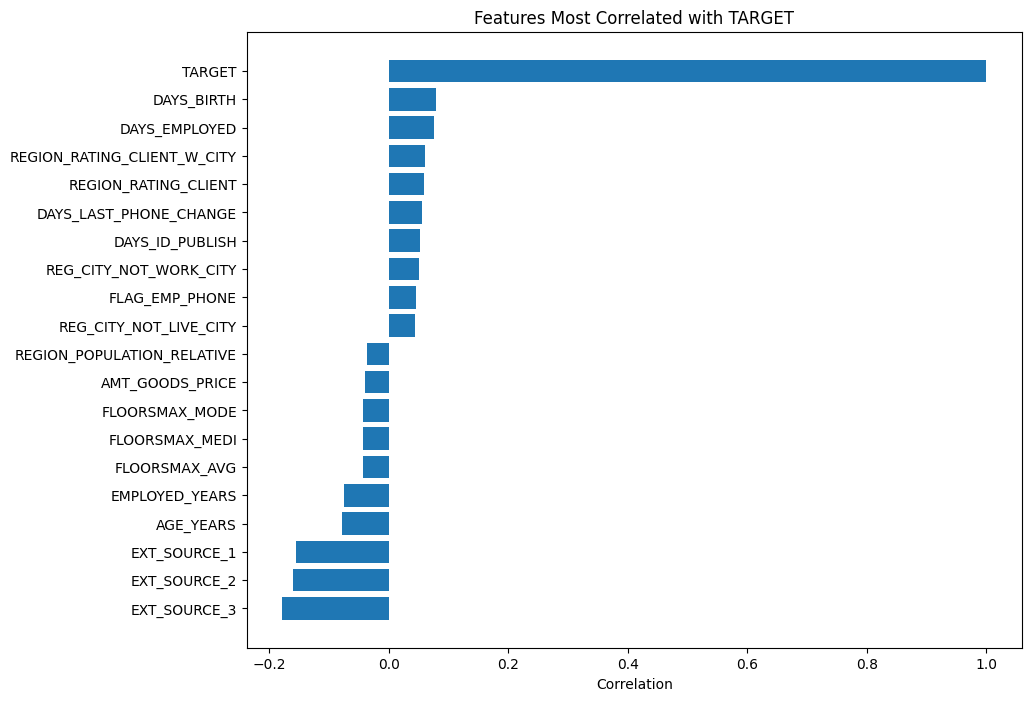

In [37]:
top_corr = pd.concat([
    correlation.head(10),
    correlation.tail(10)
])

plt.figure(figsize=(10, 8))

plt.barh(
    top_corr.index,
    top_corr.values
)

plt.title("Features Most Correlated with TARGET")
plt.xlabel("Correlation")

plt.show()

In [38]:
outlier_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE_YEARS",
    "EMPLOYED_YEARS",
    "CREDIT_INCOME_RATIO"
]

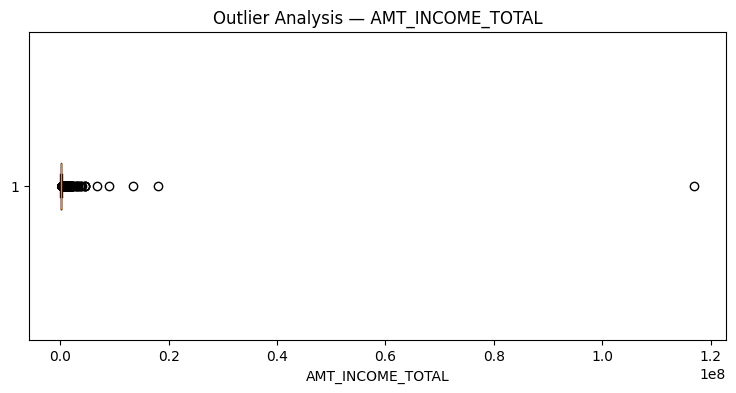

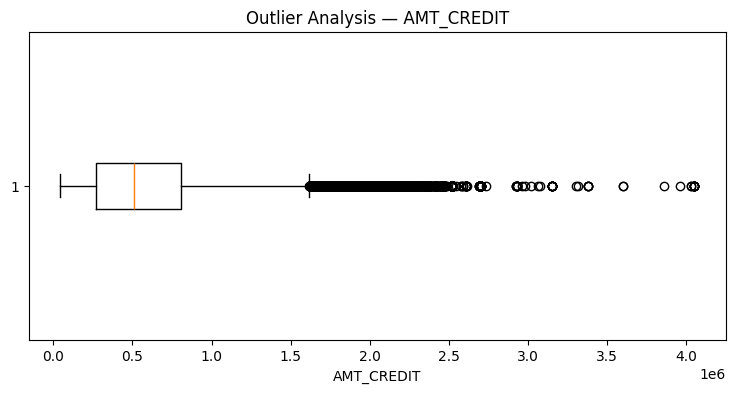

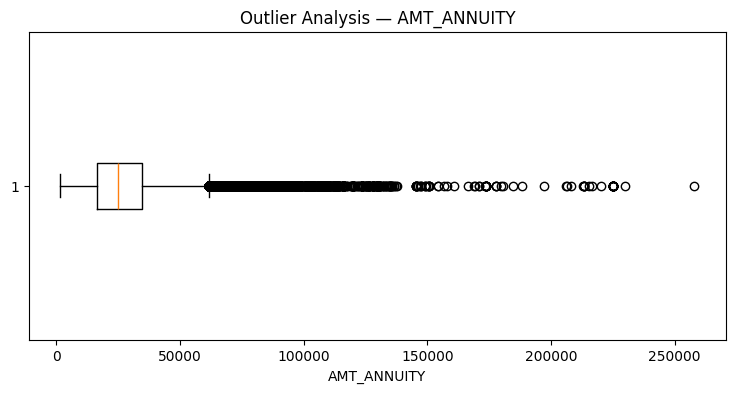

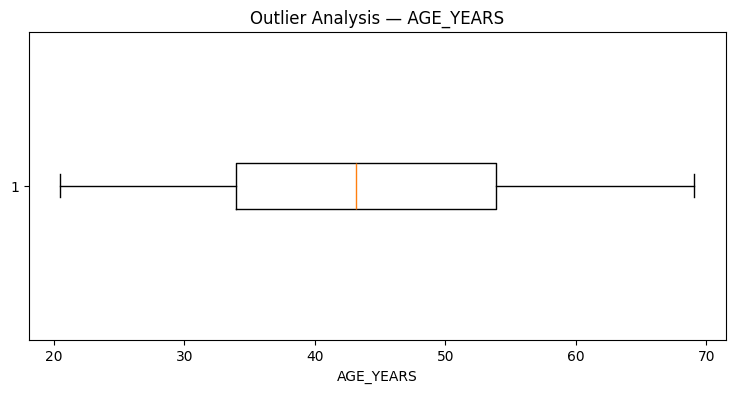

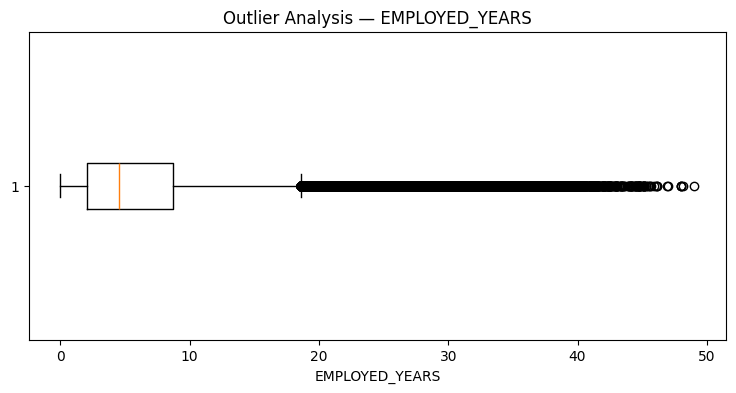

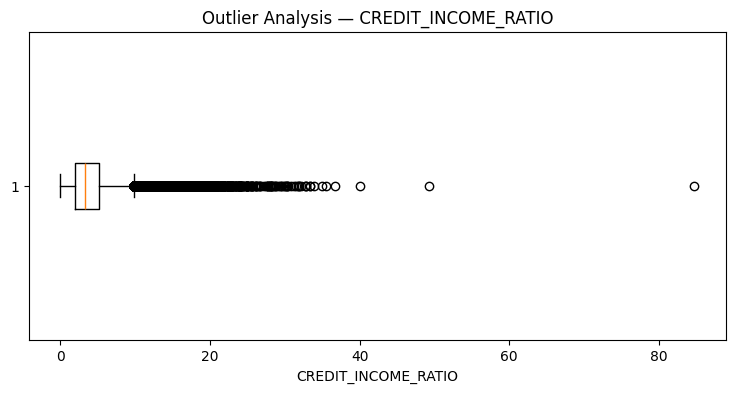

In [39]:
for col in outlier_features:

    plt.figure(figsize=(9, 4))

    plt.boxplot(
        df_train[col].dropna(),
        vert=False
    )

    plt.title(f"Outlier Analysis — {col}")
    plt.xlabel(col)

    plt.show()

In [19]:
high_missing_drop = [
    "APARTMENTS_AVG",
    "BASEMENTAREA_AVG",
    "YEARS_BUILD_AVG",
    "COMMONAREA_AVG",
    "ELEVATORS_AVG",
    "ENTRANCES_AVG",
    "FLOORSMIN_AVG",
    "LANDAREA_AVG",
    "LIVINGAPARTMENTS_AVG",
    "LIVINGAREA_AVG",
    "NONLIVINGAPARTMENTS_AVG",
    "NONLIVINGAREA_AVG",

    "APARTMENTS_MODE",
    "BASEMENTAREA_MODE",
    "YEARS_BUILD_MODE",
    "COMMONAREA_MODE",
    "ELEVATORS_MODE",
    "ENTRANCES_MODE",
    "FLOORSMIN_MODE",
    "LANDAREA_MODE",
    "LIVINGAPARTMENTS_MODE",
    "LIVINGAREA_MODE",
    "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAREA_MODE",

    "APARTMENTS_MEDI",
    "BASEMENTAREA_MEDI",
    "YEARS_BUILD_MEDI",
    "COMMONAREA_MEDI",
    "ELEVATORS_MEDI",
    "ENTRANCES_MEDI",
    "FLOORSMIN_MEDI",
    "LANDAREA_MEDI",
    "LIVINGAPARTMENTS_MEDI",
    "LIVINGAREA_MEDI",
    "NONLIVINGAPARTMENTS_MEDI",
    "NONLIVINGAREA_MEDI",

    "FONDKAPREMONT_MODE",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE"
]

In [20]:
df_clean = df_train.drop(
    columns=high_missing_drop
)

In [21]:
df_clean = df_clean.drop(
    columns=["SK_ID_CURR"]
)

In [22]:
X = df_clean.drop(
    columns=["TARGET"]
)

y = df_clean["TARGET"]

In [23]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(
    "Numerical features:",
    len(numerical_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

Numerical features: 73
Categorical features: 13


In [45]:
final_quality_report = pd.DataFrame({
    "Data_Type": X.dtypes,
    "Missing_Count": X.isnull().sum(),
    "Missing_Percentage": X.isnull().mean() * 100,
    "Unique_Values": X.nunique()
})

final_quality_report.sort_values(
    "Missing_Percentage",
    ascending=False
).head(30)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
OWN_CAR_AGE,float64,202929,65.990810,62
EXT_SOURCE_1,float64,173378,56.381073,114584
FLOORSMAX_MODE,float64,153020,49.760822,25
FLOORSMAX_AVG,float64,153020,49.760822,403
FLOORSMAX_MEDI,float64,153020,49.760822,49
YEARS_BEGINEXPLUATATION_AVG,float64,150007,48.781019,285
YEARS_BEGINEXPLUATATION_MEDI,float64,150007,48.781019,245
YEARS_BEGINEXPLUATATION_MODE,float64,150007,48.781019,221
TOTALAREA_MODE,float64,148431,48.268517,5116
EMERGENCYSTATE_MODE,object,145755,47.398304,2


In [24]:
output_path = "/content/credit_risk_cleaned.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print(
    "Saved cleaned dataset to:",
    output_path
)

Saved cleaned dataset to: /content/credit_risk_cleaned.csv


## Preprocessing & Model Training

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [48]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])

In [49]:
preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [50]:
X = df_clean.drop(columns=["TARGET"])
y = df_clean["TARGET"]

print("X:", X.shape)
print("y:", y.shape)

X: (307511, 86)
y: (307511,)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (246008, 86)
Validation: (61503, 86)


In [52]:
print(
    "Training default rate:",
    y_train.mean()
)

print(
    "Validation default rate:",
    y_val.mean()
)

Training default rate: 0.08072908198107379
Validation default rate: 0.08072776937710356


In [53]:
from sklearn.linear_model import LogisticRegression
logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        )
    )
])

In [54]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'OWN_CAR_AGE', 'FLAG_MOBIL',
                                                   'FLAG_E...
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE',
                                                   'EMERGENCYSTATE_MODE'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

In [55]:
y_pred = logistic_model.predict(X_val)

y_proba = logistic_model.predict_proba(
    X_val
)[:, 1]

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

In [57]:
print(
    "Accuracy:",
    accuracy_score(y_val, y_pred)
)

print(
    "Precision:",
    precision_score(y_val, y_pred)
)

print(
    "Recall:",
    recall_score(y_val, y_pred)
)

print(
    "F1:",
    f1_score(y_val, y_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_proba)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_proba)
)

Accuracy: 0.6727151521064013
Precision: 0.1525524699844194
Recall: 0.6704934541792548
F1: 0.24855340277000038
ROC-AUC: 0.733895808278666
PR-AUC: 0.2126803431100907


In [58]:
print(
    classification_report(
        y_val,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56538
           1       0.15      0.67      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.67      0.52     61503
weighted avg       0.89      0.67      0.75     61503



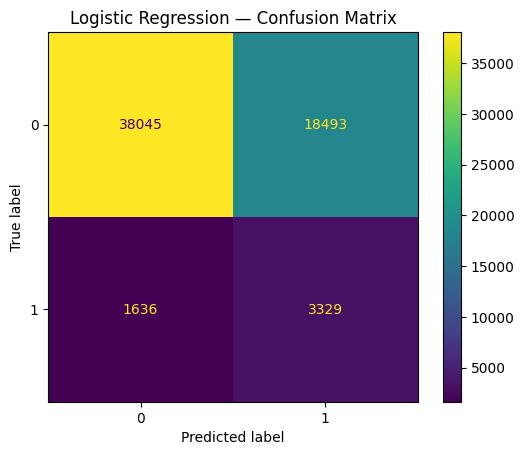

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred
)

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

## Random Forest Model

In [60]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [61]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'OWN_CAR_AGE', 'FLAG_MOBIL',
                                                   'FLAG_E...
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE',
                                                   'EMERGENCYSTATE_MODE'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [62]:
rf_pred = random_forest_model.predict(
    X_val
)

rf_proba = random_forest_model.predict_proba(
    X_val
)[:, 1]

In [63]:
print(
    "ROC-AUC:",
    roc_auc_score(y_val, rf_proba)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        rf_proba
    )
)

print(
    "Precision:",
    precision_score(y_val, rf_pred)
)

print(
    "Recall:",
    recall_score(y_val, rf_pred)
)

print(
    "F1:",
    f1_score(y_val, rf_pred)
)
print(
    "Accuracy:",
    accuracy_score(y_val, rf_pred)
)

ROC-AUC: 0.7453695198520245
PR-AUC: 0.22315389508265704
Precision: 0.2024301746688043
Recall: 0.48318227593152063
F1: 0.2853235014272122
Accuracy: 0.8045948978098629


In [64]:
print(
    classification_report(
        y_val,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.83      0.89     56538
           1       0.20      0.48      0.29      4965

    accuracy                           0.80     61503
   macro avg       0.58      0.66      0.59     61503
weighted avg       0.89      0.80      0.84     61503



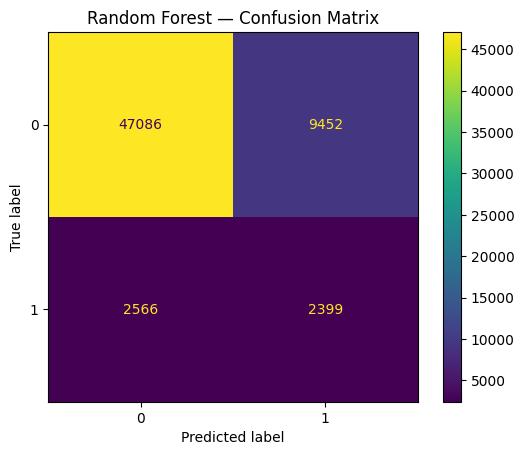

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rf_pred
)

plt.title("Random Forest — Confusion Matrix")
plt.show()

## Threshold Optimization

In [66]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:

    # Logistic Regression
    lr_predictions = (
        y_proba >= threshold
    ).astype(int)

    lr_tn, lr_fp, lr_fn, lr_tp = confusion_matrix(
        y_val,
        lr_predictions
    ).ravel()

    # Random Forest
    rf_predictions = (
        rf_proba >= threshold
    ).astype(int)

    rf_tn, rf_fp, rf_fn, rf_tp = confusion_matrix(
        y_val,
        rf_predictions
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,

        "LR_Precision": precision_score(
            y_val,
            lr_predictions,
            zero_division=0
        ),

        "LR_Recall": recall_score(
            y_val,
            lr_predictions,
            zero_division=0
        ),

        "LR_F1": f1_score(
            y_val,
            lr_predictions,
            zero_division=0
        ),

        "RF_Precision": precision_score(
            y_val,
            rf_predictions,
            zero_division=0
        ),

        "RF_Recall": recall_score(
            y_val,
            rf_predictions,
            zero_division=0
        ),

        "RF_F1": f1_score(
            y_val,
            rf_predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,LR_Precision,LR_Recall,LR_F1,RF_Precision,RF_Recall,RF_F1
0,0.10,0.081172,0.999799,0.150154,0.081009,0.999597,0.149872
1,0.15,0.082579,0.995972,0.152513,0.083481,0.995770,0.154047
2,0.20,0.085692,0.985498,0.157673,0.089750,0.979859,0.164439
3,0.25,0.090815,0.967170,0.166039,0.100180,0.943202,0.181122
4,0.30,0.098410,0.938973,0.178150,0.114701,0.884391,0.203066
5,0.35,0.108374,0.894058,0.193315,0.132305,0.803424,0.227196
6,0.40,0.120962,0.835650,0.211333,0.153122,0.707351,0.251747
7,0.45,0.134873,0.755287,0.228875,0.175423,0.595166,0.270977
8,0.50,0.152552,0.670493,0.248553,0.202430,0.483182,0.285324
9,0.55,0.174143,0.569990,0.266780,0.233891,0.369184,0.286362


## XGBOOST ON Same Data & Split

In [67]:
from xgboost import XGBClassifier
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

11.38710976837865


In [68]:
xgb_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [69]:
xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'OWN_CAR_AGE', 'FLAG_MOBIL',
                                                   'FLAG_E...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [70]:
xgb_pred = xgb_model.predict(
    X_val
)

xgb_proba = xgb_model.predict_proba(
    X_val
)[:, 1]

In [71]:
print(
    "ROC-AUC:",
    roc_auc_score(y_val, xgb_proba)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        xgb_proba
    )
)

print(
    "Precision:",
    precision_score(y_val, xgb_pred)
)

print(
    "Recall:",
    recall_score(y_val, xgb_pred)
)

print(
    "F1:",
    f1_score(y_val, xgb_pred)
)
print(
    "accuracy:",
    accuracy_score(y_val, xgb_pred)
)

ROC-AUC: 0.769285928308446
PR-AUC: 0.26084141758091584
Precision: 0.18620890311318009
Recall: 0.6445115810674723
F1: 0.28893905191873587
accuracy: 0.7439149309789767


In [72]:
results = []

models = {
    "Logistic Regression": (
        logistic_model,
        y_proba,
        y_pred
    ),
    "Random Forest": (
        random_forest_model,
        rf_proba,
        rf_pred
    ),
    "XGBoost": (
        xgb_model,
        xgb_proba,
        xgb_pred
    )
}

for name, (_, probabilities, predictions) in models.items():

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(
            y_val,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_val,
            probabilities
        ),
        "Precision": precision_score(
            y_val,
            predictions
        ),
        "Recall": recall_score(
            y_val,
            predictions
        ),
        "F1": f1_score(
            y_val,
            predictions
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
2,XGBoost,0.769286,0.260841,0.186209,0.644512,0.288939
1,Random Forest,0.745370,0.223154,0.202430,0.483182,0.285324
0,Logistic Regression,0.733896,0.212680,0.152552,0.670493,0.248553


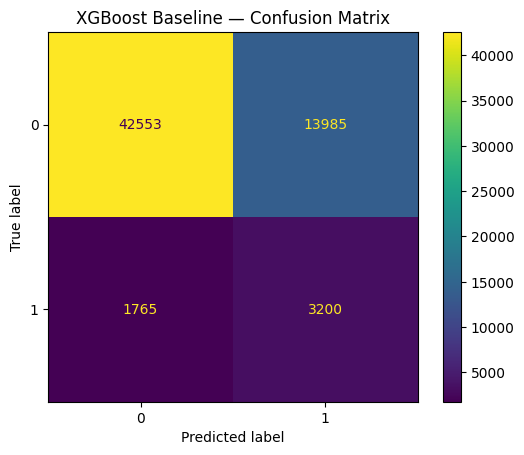

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_pred
)

plt.title("XGBoost Baseline — Confusion Matrix")
plt.show()

## Data Aggregation

In [25]:
DATA_DIR = "/root/.cache/kagglehub/competitions/home-credit-default-risk"

In [26]:
import pandas as pd
import numpy as np
import os
bureau = pd.read_csv(
    os.path.join(path, "bureau.csv")
)

bureau_balance = pd.read_csv(
    os.path.join(DATA_DIR, "bureau_balance.csv")
)

previous = pd.read_csv(
    os.path.join(DATA_DIR, "previous_application.csv")
)

pos_cash = pd.read_csv(
    os.path.join(DATA_DIR, "POS_CASH_balance.csv")
)

credit_card = pd.read_csv(
    os.path.join(DATA_DIR, "credit_card_balance.csv")
)

installments = pd.read_csv(
    os.path.join(DATA_DIR, "installments_payments.csv")
)

In [27]:
datasets = {
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous,
    "pos_cash": pos_cash,
    "credit_card": credit_card,
    "installments": installments
}

for name, data in datasets.items():
    print(
        f"{name:25} "
        f"{data.shape}"
    )

bureau                    (1716428, 17)
bureau_balance            (27299925, 3)
previous_application      (1670214, 37)
pos_cash                  (10001358, 8)
credit_card               (3840312, 23)
installments              (13605401, 8)


In [28]:
 df_train_clean = df_train.drop(
    columns=high_missing_drop
)

In [29]:
application_base = df_train_clean.copy()

In [30]:
print(application_base.shape)
print(application_base["SK_ID_CURR"].nunique())

(307511, 88)
307511


In [31]:
bureau_features = bureau[
    [
        "SK_ID_CURR",
        "SK_ID_BUREAU",
        "DAYS_CREDIT",
        "CREDIT_DAY_OVERDUE",
        "DAYS_CREDIT_ENDDATE",
        "DAYS_ENDDATE_FACT",
        "AMT_CREDIT_MAX_OVERDUE",
        "CNT_CREDIT_PROLONG",
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_LIMIT",
        "AMT_CREDIT_SUM_OVERDUE",
        "DAYS_CREDIT_UPDATE",
        "AMT_ANNUITY"
    ]
].copy()

In [32]:
bureau_features["DEBT_TO_CREDIT_RATIO"] = (
    bureau_features["AMT_CREDIT_SUM_DEBT"] /
    bureau_features["AMT_CREDIT_SUM"]
)

bureau_features["DEBT_TO_CREDIT_RATIO"] = (
    bureau_features["DEBT_TO_CREDIT_RATIO"]
    .replace([np.inf, -np.inf], np.nan)
)

In [33]:
bureau_features["HAS_OVERDUE"] = (
    bureau_features["AMT_CREDIT_SUM_OVERDUE"] > 0
).astype(int)

In [34]:
bureau_numeric = [
    "DAYS_CREDIT",
    "CREDIT_DAY_OVERDUE",
    "DAYS_CREDIT_ENDDATE",
    "DAYS_ENDDATE_FACT",
    "AMT_CREDIT_MAX_OVERDUE",
    "CNT_CREDIT_PROLONG",
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_CREDIT_SUM_OVERDUE",
    "DAYS_CREDIT_UPDATE",
    "AMT_ANNUITY",
    "DEBT_TO_CREDIT_RATIO"
]

bureau_agg = (
    bureau_features
    .groupby("SK_ID_CURR")[bureau_numeric]
    .agg(["mean", "max", "sum"])
)

bureau_agg.columns = [
    "BUREAU_" + "_".join(col)
    for col in bureau_agg.columns
]

bureau_agg = bureau_agg.reset_index()

In [35]:
bureau_count = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_CREDIT_COUNT=(
            "SK_ID_BUREAU",
            "nunique"
        )
    )
    .reset_index()
)

In [36]:
bureau_status = pd.crosstab(
    bureau["SK_ID_CURR"],
    bureau["CREDIT_ACTIVE"]
)

bureau_status.columns = [
    "BUREAU_STATUS_" +
    str(c).upper().replace(" ", "_")
    for c in bureau_status.columns
]

bureau_status = bureau_status.reset_index()

In [37]:
bureau_type = pd.crosstab(
    bureau["SK_ID_CURR"],
    bureau["CREDIT_TYPE"]
)

bureau_type.columns = [
    "BUREAU_TYPE_" +
    str(c).upper()
    .replace(" ", "_")
    .replace("-", "_")
    for c in bureau_type.columns
]

bureau_type = bureau_type.reset_index()

In [38]:
bureau_overdue = (
    bureau_features
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_OVERDUE_COUNT=(
            "HAS_OVERDUE",
            "sum"
        ),

        BUREAU_MAX_OVERDUE=(
            "AMT_CREDIT_SUM_OVERDUE",
            "max"
        )
    )
    .reset_index()
)

In [39]:
bureau_final = bureau_agg.merge(
    bureau_count,
    on="SK_ID_CURR",
    how="left"
)

bureau_final = bureau_final.merge(
    bureau_status,
    on="SK_ID_CURR",
    how="left"
)

bureau_final = bureau_final.merge(
    bureau_type,
    on="SK_ID_CURR",
    how="left"
)

bureau_final = bureau_final.merge(
    bureau_overdue,
    on="SK_ID_CURR",
    how="left"
)

In [40]:
bureau_balance_features = (
    bureau_balance
    .groupby("SK_ID_BUREAU")
    .agg(
        BB_MONTH_COUNT=(
            "MONTHS_BALANCE",
            "count"
        ),

        BB_MONTHS_MIN=(
            "MONTHS_BALANCE",
            "min"
        ),

        BB_MONTHS_MAX=(
            "MONTHS_BALANCE",
            "max"
        )
    )
    .reset_index()
)

In [41]:
bb_status = pd.crosstab(
    bureau_balance["SK_ID_BUREAU"],
    bureau_balance["STATUS"]
)

bb_status.columns = [
    "BB_STATUS_" + str(c)
    for c in bb_status.columns
]

bb_status = bb_status.reset_index()

In [42]:
bureau_balance_features = bureau_balance_features.merge(
    bb_status,
    on="SK_ID_BUREAU",
    how="left"
)

In [43]:
bureau_customer_map = bureau[
    [
        "SK_ID_CURR",
        "SK_ID_BUREAU"
    ]
].drop_duplicates()

In [44]:
bureau_balance_features = (
    bureau_customer_map
    .merge(
        bureau_balance_features,
        on="SK_ID_BUREAU",
        how="left"
    )
)

In [45]:
bureau_balance_final = (
    bureau_balance_features
    .groupby("SK_ID_CURR")
    .sum(numeric_only=True)
    .reset_index()
)

In [46]:
previous_count = (
    previous
    .groupby("SK_ID_CURR")
    .agg(
        PREVIOUS_APPLICATION_COUNT=(
            "SK_ID_PREV",
            "nunique"
        )
    )
    .reset_index()
)

In [47]:
previous_numeric = [
    "AMT_ANNUITY",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_DOWN_PAYMENT",
    "AMT_GOODS_PRICE",
    "RATE_DOWN_PAYMENT",
    "DAYS_DECISION",
    "CNT_PAYMENT"
]

previous_numeric = [
    c for c in previous_numeric
    if c in previous.columns
]

In [48]:
previous_agg = (
    previous
    .groupby("SK_ID_CURR")[previous_numeric]
    .agg(["mean", "max", "min"])
)

previous_agg.columns = [
    "PREV_" + "_".join(col)
    for col in previous_agg.columns
]

previous_agg = previous_agg.reset_index()

In [49]:
previous_status = pd.crosstab(
    previous["SK_ID_CURR"],
    previous["NAME_CONTRACT_STATUS"]
)

previous_status.columns = [
    "PREV_STATUS_" +
    str(c).upper()
    .replace(" ", "_")
    for c in previous_status.columns
]

previous_status = previous_status.reset_index()

In [50]:
previous_final = previous_count.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left"
)

previous_final = previous_final.merge(
    previous_status,
    on="SK_ID_CURR",
    how="left"
)

In [51]:
previous["IS_REFUSED"] = (
    previous["NAME_CONTRACT_STATUS"]
    == "Refused"
).astype(int)

previous["IS_APPROVED"] = (
    previous["NAME_CONTRACT_STATUS"]
    == "Approved"
).astype(int)

In [52]:
previous_rates = (
    previous
    .groupby("SK_ID_CURR")
    .agg(
        PREV_REFUSAL_RATE=(
            "IS_REFUSED",
            "mean"
        ),

        PREV_APPROVAL_RATE=(
            "IS_APPROVED",
            "mean"
        )
    )
    .reset_index()
)

In [53]:
previous_final = previous_final.merge(
    previous_rates,
    on="SK_ID_CURR",
    how="left"
)

In [54]:
pos_count = (
    pos_cash
    .groupby("SK_ID_CURR")
    .agg(
        POS_LOAN_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        POS_MONTH_COUNT=(
            "MONTHS_BALANCE",
            "count"
        )
    )
    .reset_index()
)

In [55]:
pos_numeric = [
    "MONTHS_BALANCE",
    "CNT_INSTALMENT",
    "CNT_INSTALMENT_FUTURE"
]

pos_numeric = [
    c for c in pos_numeric
    if c in pos_cash.columns
]

In [56]:
pos_agg = (
    pos_cash
    .groupby("SK_ID_CURR")[pos_numeric]
    .agg(["mean", "max", "min"])
)

pos_agg.columns = [
    "POS_" + "_".join(col)
    for col in pos_agg.columns
]

pos_agg = pos_agg.reset_index()

In [57]:
pos_status = pd.crosstab(
    pos_cash["SK_ID_CURR"],
    pos_cash["NAME_CONTRACT_STATUS"]
)

pos_status.columns = [
    "POS_STATUS_" +
    str(c).upper()
    .replace(" ", "_")
    for c in pos_status.columns
]

pos_status = pos_status.reset_index()

In [58]:
pos_final = pos_count.merge(
    pos_agg,
    on="SK_ID_CURR",
    how="left"
)

pos_final = pos_final.merge(
    pos_status,
    on="SK_ID_CURR",
    how="left"
)

In [59]:
cc_count = (
    credit_card
    .groupby("SK_ID_CURR")
    .agg(
        CREDIT_CARD_COUNT=(
            "SK_ID_PREV",
            "nunique"
        )
    )
    .reset_index()
)

In [60]:
cc_numeric = [
    "AMT_BALANCE",
    "AMT_CREDIT_LIMIT_ACTUAL",
    "AMT_DRAWINGS_ATM_CURRENT",
    "AMT_DRAWINGS_CURRENT",
    "AMT_PAYMENT_CURRENT",
    "AMT_PAYMENT_TOTAL_CURRENT",
    "AMT_RECEIVABLE_PRINCIPAL",
    "AMT_RECIVABLE",
    "AMT_TOTAL_RECEIVABLE",
    "CNT_DRAWINGS_ATM_CURRENT",
    "CNT_DRAWINGS_CURRENT",
    "CNT_INSTALMENT_MATURE_CUM",
    "CNT_INSTALMENT_FUTURE",
    "SK_DPD",
    "SK_DPD_DEF"
]

cc_numeric = [
    c for c in cc_numeric
    if c in credit_card.columns
]

In [61]:
cc_agg = (
    credit_card
    .groupby("SK_ID_CURR")[cc_numeric]
    .agg(["mean", "max"])
)

cc_agg.columns = [
    "CC_" + "_".join(col)
    for col in cc_agg.columns
]

cc_agg = cc_agg.reset_index()

In [62]:
credit_card["CC_UTILIZATION"] = (
    credit_card["AMT_BALANCE"] /
    credit_card["AMT_CREDIT_LIMIT_ACTUAL"]
)

credit_card["CC_UTILIZATION"] = (
    credit_card["CC_UTILIZATION"]
    .replace([np.inf, -np.inf], np.nan)
)

In [63]:
cc_utilization = (
    credit_card
    .groupby("SK_ID_CURR")
    ["CC_UTILIZATION"]
    .agg(["mean", "max"])
    .reset_index()
)

cc_utilization.columns = [
    "SK_ID_CURR",
    "CC_UTILIZATION_MEAN",
    "CC_UTILIZATION_MAX"
]

In [64]:
cc_final = cc_count.merge(
    cc_agg,
    on="SK_ID_CURR",
    how="left"
)

cc_final = cc_final.merge(
    cc_utilization,
    on="SK_ID_CURR",
    how="left"
)

In [65]:
installments["PAYMENT_DELAY"] = (
    installments["DAYS_ENTRY_PAYMENT"]
    -
    installments["DAYS_INSTALMENT"]
)

In [66]:
installments["PAYMENT_DIFF"] = (
    installments["AMT_PAYMENT"]
    -
    installments["AMT_INSTALMENT"]
)

In [67]:
installments["PAYMENT_RATIO"] = (
    installments["AMT_PAYMENT"] /
    installments["AMT_INSTALMENT"]
)

installments["PAYMENT_RATIO"] = (
    installments["PAYMENT_RATIO"]
    .replace([np.inf, -np.inf], np.nan)
)

In [68]:
installments["IS_LATE"] = (
    installments["PAYMENT_DELAY"] > 0
).astype(int)

In [69]:
installments["IS_UNDERPAID"] = (
    installments["PAYMENT_DIFF"] < 0
).astype(int)

In [70]:
installment_final = (
    installments
    .groupby("SK_ID_CURR")
    .agg(
        INSTALLMENT_COUNT=(
            "SK_ID_PREV",
            "count"
        ),

        AVG_PAYMENT_DELAY=(
            "PAYMENT_DELAY",
            "mean"
        ),

        MAX_PAYMENT_DELAY=(
            "PAYMENT_DELAY",
            "max"
        ),

        LATE_PAYMENT_COUNT=(
            "IS_LATE",
            "sum"
        ),

        LATE_PAYMENT_RATE=(
            "IS_LATE",
            "mean"
        ),

        AVG_PAYMENT_DIFF=(
            "PAYMENT_DIFF",
            "mean"
        ),

        AVG_PAYMENT_RATIO=(
            "PAYMENT_RATIO",
            "mean"
        ),

        MAX_PAYMENT_RATIO=(
            "PAYMENT_RATIO",
            "max"
        ),

        UNDERPAYMENT_COUNT=(
            "IS_UNDERPAID",
            "sum"
        )
    )
    .reset_index()
)

In [72]:
final_df = application_base.copy()

In [73]:
final_df = final_df.merge(
    bureau_final,
    on="SK_ID_CURR",
    how="left"
)

In [74]:
final_df = final_df.merge(
    bureau_balance_final,
    on="SK_ID_CURR",
    how="left"
)

In [75]:
final_df = final_df.merge(
    previous_final,
    on="SK_ID_CURR",
    how="left"
)

In [76]:
final_df = final_df.merge(
    pos_final,
    on="SK_ID_CURR",
    how="left"
)

In [77]:
final_df = final_df.merge(
    cc_final,
    on="SK_ID_CURR",
    how="left"
)

In [78]:
final_df = final_df.merge(
    installment_final,
    on="SK_ID_CURR",
    how="left"
)

In [79]:
print("Final shape:", final_df.shape)

print(
    "Rows:",
    len(final_df)
)

print(
    "Unique SK_ID_CURR:",
    final_df["SK_ID_CURR"].nunique()
)

print(
    "Duplicate rows:",
    final_df["SK_ID_CURR"].duplicated().sum()
)

Final shape: (307511, 252)
Rows: 307511
Unique SK_ID_CURR: 307511
Duplicate rows: 0


In [80]:
print(
    "Total features:",
    final_df.shape[1]
)

Total features: 252


In [81]:
application_columns = set(
    application_base.columns
)

new_features = [
    col for col in final_df.columns
    if col not in application_columns
]

print(
    "New historical features:",
    len(new_features)
)

New historical features: 164


In [82]:
print(new_features)

['BUREAU_DAYS_CREDIT_mean', 'BUREAU_DAYS_CREDIT_max', 'BUREAU_DAYS_CREDIT_sum', 'BUREAU_CREDIT_DAY_OVERDUE_mean', 'BUREAU_CREDIT_DAY_OVERDUE_max', 'BUREAU_CREDIT_DAY_OVERDUE_sum', 'BUREAU_DAYS_CREDIT_ENDDATE_mean', 'BUREAU_DAYS_CREDIT_ENDDATE_max', 'BUREAU_DAYS_CREDIT_ENDDATE_sum', 'BUREAU_DAYS_ENDDATE_FACT_mean', 'BUREAU_DAYS_ENDDATE_FACT_max', 'BUREAU_DAYS_ENDDATE_FACT_sum', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_mean', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_max', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_sum', 'BUREAU_CNT_CREDIT_PROLONG_mean', 'BUREAU_CNT_CREDIT_PROLONG_max', 'BUREAU_CNT_CREDIT_PROLONG_sum', 'BUREAU_AMT_CREDIT_SUM_mean', 'BUREAU_AMT_CREDIT_SUM_max', 'BUREAU_AMT_CREDIT_SUM_sum', 'BUREAU_AMT_CREDIT_SUM_DEBT_mean', 'BUREAU_AMT_CREDIT_SUM_DEBT_max', 'BUREAU_AMT_CREDIT_SUM_DEBT_sum', 'BUREAU_AMT_CREDIT_SUM_LIMIT_mean', 'BUREAU_AMT_CREDIT_SUM_LIMIT_max', 'BUREAU_AMT_CREDIT_SUM_LIMIT_sum', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_mean', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_max', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_sum',

In [85]:
print(final_df.shape)
print(final_df["SK_ID_CURR"].nunique())
print(final_df["SK_ID_CURR"].duplicated().sum())
print(len(new_features))

(307511, 252)
307511
0
164


In [86]:
# Missing percentage
missing = (
    final_df.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

print(missing.head(30))

CC_AMT_PAYMENT_CURRENT_max           80.143800
CC_AMT_PAYMENT_CURRENT_mean          80.143800
CC_AMT_DRAWINGS_ATM_CURRENT_max      80.117784
CC_AMT_DRAWINGS_ATM_CURRENT_mean     80.117784
CC_CNT_DRAWINGS_ATM_CURRENT_mean     80.117784
CC_CNT_DRAWINGS_ATM_CURRENT_max      80.117784
BUREAU_AMT_ANNUITY_max               73.981744
BUREAU_AMT_ANNUITY_mean              73.981744
CC_UTILIZATION_MAX                   72.021814
CC_UTILIZATION_MEAN                  72.021814
CC_AMT_RECEIVABLE_PRINCIPAL_max      71.739222
CC_AMT_TOTAL_RECEIVABLE_max          71.739222
CC_SK_DPD_mean                       71.739222
CC_AMT_PAYMENT_TOTAL_CURRENT_max     71.739222
CC_SK_DPD_max                        71.739222
CC_SK_DPD_DEF_mean                   71.739222
CC_CNT_DRAWINGS_CURRENT_max          71.739222
CC_CNT_INSTALMENT_MATURE_CUM_max     71.739222
CC_CNT_INSTALMENT_MATURE_CUM_mean    71.739222
CC_AMT_BALANCE_mean                  71.739222
CC_AMT_RECEIVABLE_PRINCIPAL_mean     71.739222
CC_SK_DPD_DEF

In [87]:
# Constant features
constant_features = [
    col for col in final_df.columns
    if final_df[col].nunique(dropna=False) <= 1
]

print("Constant features:", len(constant_features))
print(constant_features)

Constant features: 0
[]


In [88]:
# Duplicate columns
duplicate_columns = []

columns = final_df.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if final_df[columns[i]].equals(final_df[columns[j]]):
            duplicate_columns.append(columns[j])

print("Duplicate columns:", len(duplicate_columns))
duplicate_columns

Duplicate columns: 1


['BUREAU_MAX_OVERDUE']

In [89]:
final_df = final_df.drop(
    columns=duplicate_columns
)

In [90]:
history_cols = [
    "BUREAU_CREDIT_COUNT",
    "PREVIOUS_APPLICATION_COUNT",
    "POS_LOAN_COUNT",
    "CREDIT_CARD_COUNT",
    "INSTALLMENT_COUNT"
]

print(final_df[history_cols].isna().mean() * 100)

BUREAU_CREDIT_COUNT           14.314935
PREVIOUS_APPLICATION_COUNT     5.350703
POS_LOAN_COUNT                 5.875237
CREDIT_CARD_COUNT             71.739222
INSTALLMENT_COUNT              5.160141
dtype: float64


In [91]:
final_df["HAS_BUREAU_HISTORY"] = (
    final_df["BUREAU_CREDIT_COUNT"].notna()
).astype(int)

final_df["HAS_PREVIOUS_APPLICATION"] = (
    final_df["PREVIOUS_APPLICATION_COUNT"].notna()
).astype(int)

final_df["HAS_POS_HISTORY"] = (
    final_df["POS_LOAN_COUNT"].notna()
).astype(int)

final_df["HAS_CREDIT_CARD_HISTORY"] = (
    final_df["CREDIT_CARD_COUNT"].notna()
).astype(int)

final_df["HAS_INSTALLMENT_HISTORY"] = (
    final_df["INSTALLMENT_COUNT"].notna()
).astype(int)

In [92]:
history_flags = [
    "HAS_BUREAU_HISTORY",
    "HAS_PREVIOUS_APPLICATION",
    "HAS_POS_HISTORY",
    "HAS_CREDIT_CARD_HISTORY",
    "HAS_INSTALLMENT_HISTORY"
]

print(final_df[history_flags].mean() * 100)

HAS_BUREAU_HISTORY          85.685065
HAS_PREVIOUS_APPLICATION    94.649297
HAS_POS_HISTORY             94.124763
HAS_CREDIT_CARD_HISTORY     28.260778
HAS_INSTALLMENT_HISTORY     94.839859
dtype: float64


In [93]:
OUTPUT_FILE = (
    "/content/"
    "home_credit_feature_engineered.csv"
)

final_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"Saved to: {OUTPUT_FILE}"
)

Saved to: /content/home_credit_feature_engineered.csv


In [94]:
DRIVE_OUTPUT_FILE = '/content/drive/MyDrive/home_credit_feature_engineered.csv'

# 3. Export directly to Drive
final_df.to_csv(DRIVE_OUTPUT_FILE, index=False)
print(f"File successfully saved to Google Drive at: {DRIVE_OUTPUT_FILE}")

File successfully saved to Google Drive at: /content/drive/MyDrive/home_credit_feature_engineered.csv


In [95]:
final_df.shape

(307511, 256)

In [3]:
import pandas as pd
final_df = pd.read_csv("/content/home_credit_feature_engineered.csv")
final_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,LATE_PAYMENT_RATE,AVG_PAYMENT_DIFF,AVG_PAYMENT_RATIO,MAX_PAYMENT_RATIO,UNDERPAYMENT_COUNT,HAS_BUREAU_HISTORY,HAS_PREVIOUS_APPLICATION,HAS_POS_HISTORY,HAS_CREDIT_CARD_HISTORY,HAS_INSTALLMENT_HISTORY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.000000,0.000000,1.000000,1.0,0.0,1,1,1,0,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.000000,0.000000,1.000000,1.0,0.0,1,1,1,0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.000000,0.000000,1.000000,1.0,0.0,1,1,1,0,1
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.000000,0.000000,1.000000,1.0,0.0,0,1,1,1,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.242424,-452.384318,0.954545,1.0,6.0,1,1,1,0,1


## Data Split

In [4]:
from sklearn.model_selection import train_test_split

# Separate target and ID
X = final_df.drop(
    columns=["TARGET", "SK_ID_CURR"]
)

y = final_df["TARGET"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

X shape: (307511, 254)
y shape: (307511,)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print("Training:", X_train.shape)
print("Validation:", X_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

Training: (246008, 254)
Validation: (61503, 254)

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


## Preprocessing

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 241
Categorical features: 13


In [7]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [8]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [10]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

In [11]:
print(
    "Training processed shape:",
    X_train_processed.shape
)

print(
    "Validation processed shape:",
    X_val_processed.shape
)

Training processed shape: (246008, 367)
Validation processed shape: (61503, 367)


Scale_pos_weight Calculation

In [12]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print(
    "scale_pos_weight:",
    scale_pos_weight
)

Negative: 226148
Positive: 19860
scale_pos_weight: 11.38710976837865


## XGBoost BaseLine Model

In [13]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

In [14]:
xgb_baseline.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [15]:
y_prob_baseline = xgb_baseline.predict_proba(
    X_val_processed
)[:, 1]

## Evaluation

In [16]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred_baseline = (
    y_prob_baseline >= 0.50
).astype(int)

roc_auc = roc_auc_score(
    y_val,
    y_prob_baseline
)

pr_auc = average_precision_score(
    y_val,
    y_prob_baseline
)

precision = precision_score(
    y_val,
    y_pred_baseline
)

recall = recall_score(
    y_val,
    y_pred_baseline
)

f1 = f1_score(
    y_val,
    y_pred_baseline
)

print("ROC-AUC :", roc_auc)
print("PR-AUC  :", pr_auc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_baseline))

ROC-AUC : 0.7884913361303008
PR-AUC  : 0.2877295603796117
Precision: 0.2067329272202629
Recall   : 0.6493454179254784
F1       : 0.31361867704280155

Confusion Matrix:
[[44167 12371]
 [ 1741  3224]]


In [17]:
print(
    classification_report(
        y_val,
        y_pred_baseline,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9621    0.7812    0.8622     56538
           1     0.2067    0.6493    0.3136      4965

    accuracy                         0.7705     61503
   macro avg     0.5844    0.7153    0.5879     61503
weighted avg     0.9011    0.7705    0.8180     61503



## HyperParameter Tuning

In [18]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "n_estimators": [
        300,
        500,
        700,
        1000
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08,
        0.1
    ],

    "max_depth": [
        3,
        4,
        5,
        6,
        7,
        8
    ],

    "min_child_weight": [
        1,
        3,
        5,
        10
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "gamma": [
        0,
        0.1,
        0.3,
        0.5
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],

    "reg_lambda": [
        1,
        2,
        5,
        10
    ]
}

In [22]:
# Force n_jobs=1 on estimator to prevent thread duplication
xgb_tuning = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=1,  # CRITICAL: Prevents XGBoost from competing with Search workers
    tree_method="hist",  # Keeps memory low via histogram binning
)

In [25]:
import gc
from sklearn.model_selection import RandomizedSearchCV

# Downcast feature matrix to float32 to reduce memory footprint by 50%
X_train_processed = X_train_processed.astype("float32")

# Run garbage collection before search
gc.collect()

random_search = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_grid,
    n_iter=10,  # Keep search iterations modest
    cv=3,  # Use 3-fold CV instead of 5-fold to conserve memory
    scoring="roc_auc",
    n_jobs=1,  # CRITICAL: Forces single-process execution (no RAM cloning)
    verbose=2,
    random_state=42,
)

random_search.fit(X_train_processed, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=2, subsample=0.9; total time= 2.2min
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=2, subsample=0.9; total time= 2.0min
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=2, subsample=0.9; total time= 2.0min
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=500, reg_alpha=0.01, reg_lambda=10, subsample=0.7; total time= 1.4min
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=500, reg_alpha=0.01, reg_lambda=10, subsample=0.7; total time= 1.4min
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.03, 

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='aucpr',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constra...
                   n_jobs=1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.08, 0.1],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [300, 500, 700, 1000],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [1, 2, 5, 10],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [28]:
print("Best ROC-AUC:")
print(random_search.best_score_)

Best ROC-AUC:
0.7839368457346962


In [27]:
print("\nBest Parameters:")
print(random_search.best_params_)


Best Parameters:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


## Best Model Selection

In [29]:
final_xgb = random_search.best_estimator_

In [30]:
y_prob = final_xgb.predict_proba(
    X_val_processed
)[:, 1]

y_pred = (
    y_prob >= 0.50
).astype(int)

In [31]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

roc_auc = roc_auc_score(
    y_val,
    y_prob
)

pr_auc = average_precision_score(
    y_val,
    y_prob
)

precision = precision_score(
    y_val,
    y_pred
)

recall = recall_score(
    y_val,
    y_pred
)

f1 = f1_score(
    y_val,
    y_pred
)

print("Final Tuned XGBoost")
print("======================")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Final Tuned XGBoost
ROC-AUC  : 0.7881
PR-AUC   : 0.2885
Precision: 0.1900
Recall   : 0.6985
F1       : 0.2987

Confusion Matrix:
[[41754 14784]
 [ 1497  3468]]


In [32]:
print(
    classification_report(
        y_val,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9654    0.7385    0.8368     56538
           1     0.1900    0.6985    0.2987      4965

    accuracy                         0.7353     61503
   macro avg     0.5777    0.7185    0.5678     61503
weighted avg     0.9028    0.7353    0.7934     61503



## Threshold Optimization

In [33]:
import numpy as np
import pandas as pd

threshold_results = []

for threshold in np.arange(0.10, 0.71, 0.05):

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),

        "Precision": precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),

        "F1": f1_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.085419,0.993152,0.157309
1,0.15,0.092629,0.980262,0.169263
2,0.20,0.101480,0.955690,0.183477
3,0.25,0.112468,0.927291,0.200606
4,0.30,0.124534,0.894260,0.218622
5,0.35,0.137668,0.851964,0.237035
6,0.40,0.152996,0.805841,0.257167
7,0.45,0.171320,0.755086,0.279276
8,0.50,0.190007,0.698489,0.298747
9,0.55,0.210498,0.632427,0.315864


In [34]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_threshold)

Threshold    0.700000
Precision    0.301238
Recall       0.396979
F1           0.342544
Name: 12, dtype: float64


## Visualization

/tmp/ipykernel_10700/3714234153.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


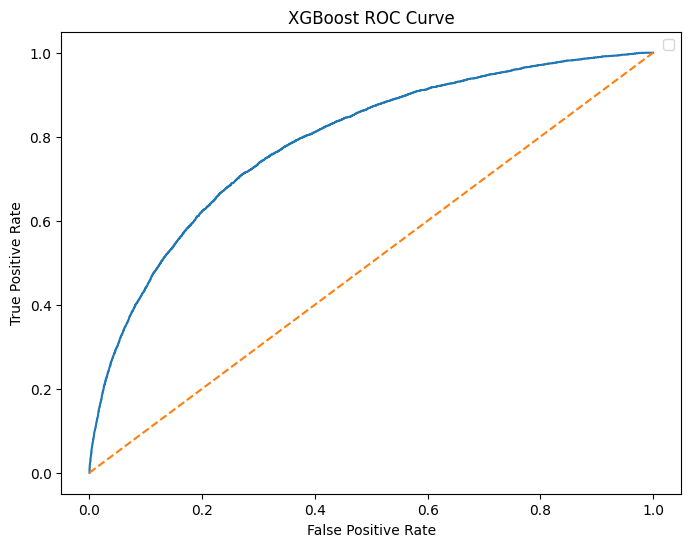

In [36]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

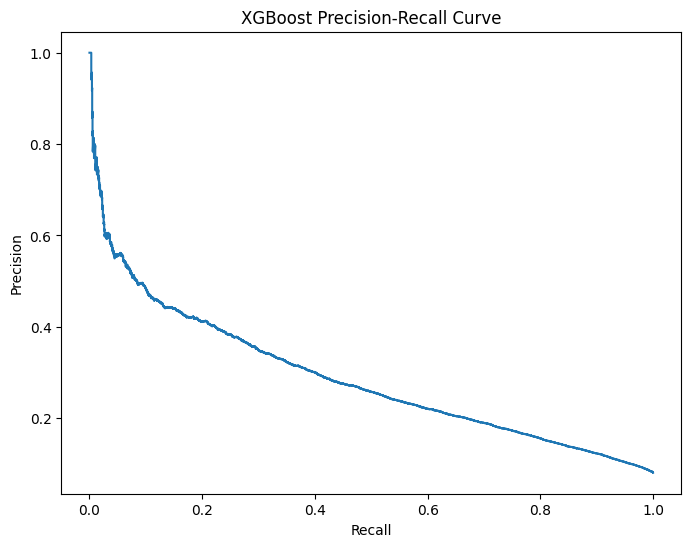

In [37]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_val,
        y_prob
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")

plt.show()

##SHAP Explainability

In [38]:
!pip install shap -q

In [39]:
import shap
explainer = shap.TreeExplainer(
    final_xgb
)

In [40]:
sample_size = min(
    5000,
    X_val_processed.shape[0]
)

sample_indices = np.random.RandomState(
    42
).choice(
    X_val_processed.shape[0],
    size=sample_size,
    replace=False
)

X_shap = X_val_processed[
    sample_indices
]

In [41]:
shap_values = explainer(
    X_shap
)

In [43]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)
print(
    len(feature_names)
)

print(
    feature_names[:20]
)

367
['num__CNT_CHILDREN' 'num__AMT_INCOME_TOTAL' 'num__AMT_CREDIT'
 'num__AMT_ANNUITY' 'num__AMT_GOODS_PRICE'
 'num__REGION_POPULATION_RELATIVE' 'num__DAYS_BIRTH' 'num__DAYS_EMPLOYED'
 'num__DAYS_REGISTRATION' 'num__DAYS_ID_PUBLISH' 'num__OWN_CAR_AGE'
 'num__FLAG_MOBIL' 'num__FLAG_EMP_PHONE' 'num__FLAG_WORK_PHONE'
 'num__FLAG_CONT_MOBILE' 'num__FLAG_PHONE' 'num__FLAG_EMAIL'
 'num__CNT_FAM_MEMBERS' 'num__REGION_RATING_CLIENT'
 'num__REGION_RATING_CLIENT_W_CITY']


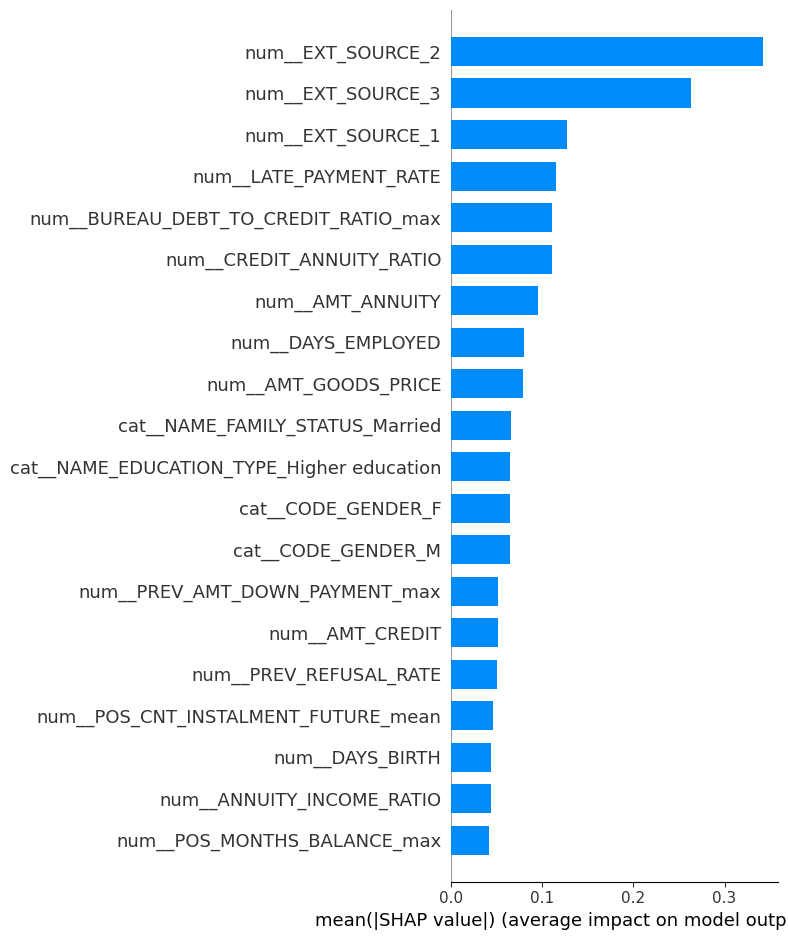

In [45]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

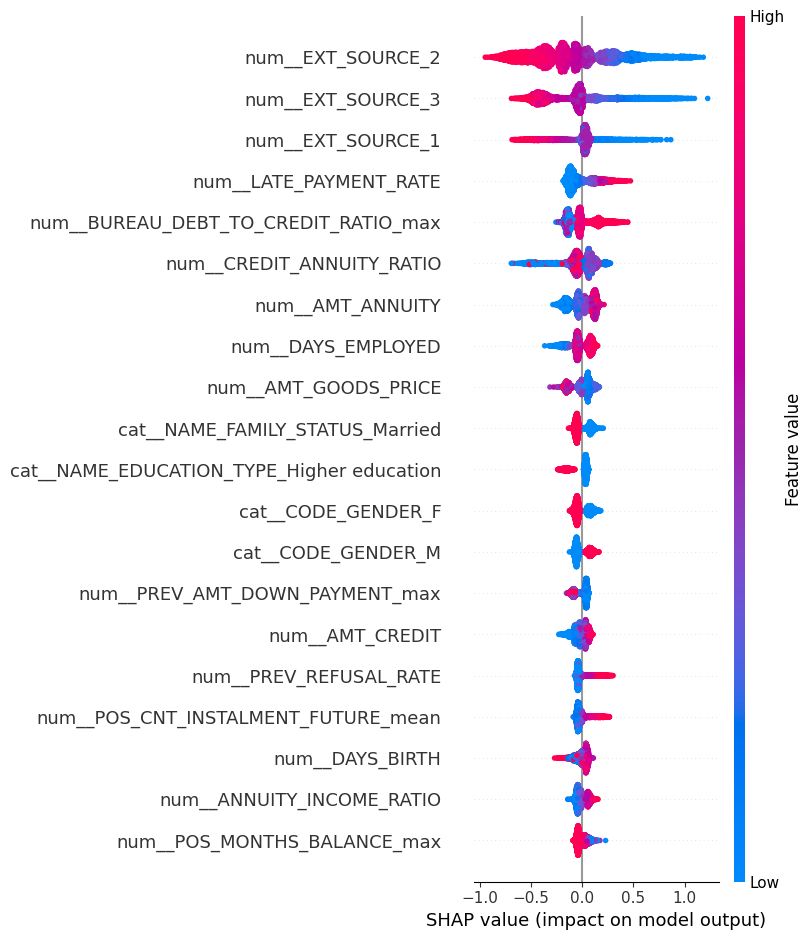

In [46]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20
)

In [50]:
applicant_idx = 0
X_applicant = X_val_processed[applicant_idx:applicant_idx+1]
shap_values = explainer.shap_values(X_applicant)

In [52]:
import pandas as pd

local_shap = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values[0]
})

local_shap["abs_shap"] = local_shap["shap_value"].abs()

local_shap = local_shap.sort_values(
    "abs_shap",
    ascending=False
)

top_features = local_shap.head(10)

print(top_features)

                                       feature  shap_value  abs_shap
28                           num__EXT_SOURCE_2   -0.243928  0.243928
266  cat__NAME_EDUCATION_TYPE_Higher education   -0.180138  0.180138
226                    num__CC_UTILIZATION_MAX   -0.168246  0.168246
4                         num__AMT_GOODS_PRICE   -0.152083  0.152083
231                     num__LATE_PAYMENT_RATE   -0.130317  0.130317
7                           num__DAYS_EMPLOYED    0.119163  0.119163
3                             num__AMT_ANNUITY    0.116875  0.116875
97       num__BUREAU_AMT_CREDIT_SUM_LIMIT_mean   -0.102418  0.102418
66              num__AMT_REQ_CREDIT_BUREAU_QRT   -0.088262  0.088262
72                   num__CREDIT_ANNUITY_RATIO   -0.082798  0.082798


## Model Dump

In [53]:
import joblib

joblib.dump(
    final_xgb,
    "credit_risk_xgboost.joblib"
)

joblib.dump(
    explainer,
    "credit_risk_shap_explainer.joblib"
)

joblib.dump(
    preprocessor,
    "credit_risk_preprocessor.joblib"
)

['credit_risk_preprocessor.joblib']